# Part II Evaluations (+ F: method comparison + H)

# Further evaluations 
**Responsible:** 

3.6.1 Settings and Protocol _(Joao, F)_

3.6.2 Base Heuristics _(Joao, A)_

3.6.3 Batch Allocation _(Cam, B)_

3.6.4 Kunkler Formalization _(Thomas, C)_

3.6.5 Park Formalization _(Joao, C)_

Placeholder
...

## RL policy vs. reference baselines 
**Responsible:**  _(Aldo Patrone)_

All allocation methods on the data-calibrated case-based environment (arrival rate and case length matched to the real BPIC-17 log), scored on the disclosed equal-weight combined objective (cycle time + fairness, lower = better). The baselines are random, round-robin, shortest-queue and an experience-greedy ablation. The RL policies come from 2.4_rl_allocation.

Honest finding: both RL agents learn sensible trade-offs and beat random, round-robin and most-experienced, but shortest-queue (load-balancing) remains the best: balancing serves *both* fairness (directly) and cycle time (via availability). The reward was aligned to the objective but not tuned to this score. This is the standalone comparison. The full cross-method evaluation on the integrated simulator uses compare_on_sim from 2.5_metrics.

           method  cycle_time_h  load_gini  combined
   shortest-queue         12.16      0.236     0.850
PPO (MaskablePPO)         12.45      0.259     0.897
   RL (REINFORCE)         11.54      0.297     0.921
 most-experienced         11.44      0.321     0.954
           random         12.43      0.297     0.956
      round-robin         12.60      0.302     0.970
saved ../results/allocation_comparison.png


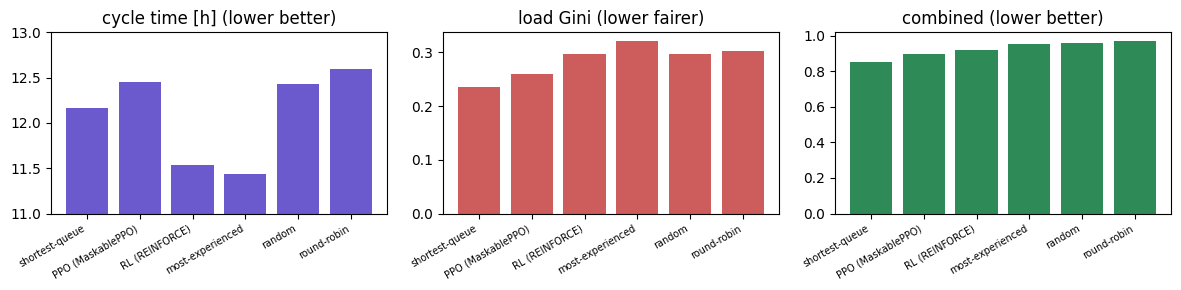

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
cmp = pd.read_csv('../results/allocation_comparison.csv')
print(cmp.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].bar(cmp['method'], cmp['cycle_time_h'], color='slateblue')
axes[0].set_title('cycle time [h] (lower better)'); axes[0].set_ylim(11, 13)
axes[1].bar(cmp['method'], cmp['load_gini'], color='indianred')
axes[1].set_title('load Gini (lower fairer)')
axes[2].bar(cmp['method'], cmp['combined'], color='seagreen')
axes[2].set_title('combined (lower better)')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha('right'); lbl.set_fontsize(7)
fig.tight_layout(); fig.savefig('../results/allocation_comparison.png', dpi=120)
print('saved ../results/allocation_comparison.png')

# Further evaluations 
**Responsible:** 

3.6.7 Cross-Method Synthesis _(Joao, F)_

3.6.8 Slide-23 Question _(Cam, H)_

Placeholder
...